<a href="https://colab.research.google.com/github/farahnda/Learning/blob/main/Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
dataset = pd.read_csv('position_salaries.csv')

In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [21]:
dataset.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [6]:
# tentuin x & y
X = dataset.iloc[:, 1:2].values # ambil kolom ke-1 (level)
# (sklearn butuh 2 dimensi/matriks:
# [[1],
#  [2]
#  [3]] makanya 1:2)
y = dataset.iloc[:, 2].values # ambil kolom salary

In [7]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

In [22]:
# LINEAR REGRESSION
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression() #
lin_reg.fit(X, y) # proses belajarnya, liat x & y tadi trus cari garis lurus terbaik
# kalo secara mtk y = a + bx

LinearRegression()

In [13]:
def viz_linear():
  plt.scatter(X, y, color='red') # buat tiitk merah
  plt.plot(X, lin_reg.predict(X), color='blue') # buat garisnya
  plt.title('Linear Regression model')
  plt.xlabel('Position Level')
  plt.ylabel('Salary')
  plt.show()
  return

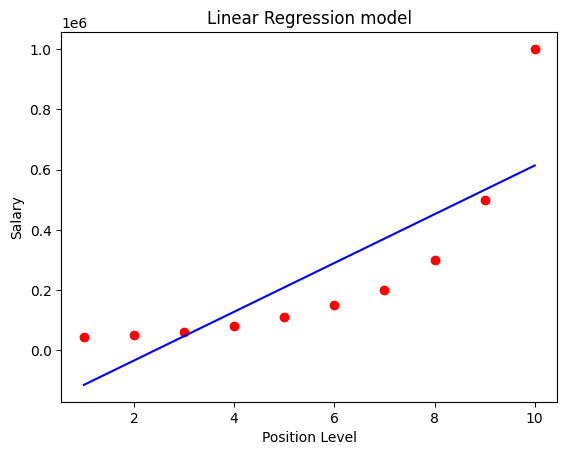

In [14]:
viz_linear()

In [43]:
# POLYNOMIAL REGRESSION
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree =4) # ubah fitur x jadi 1 x x^2 x^3 dst kalau Level = 5 => 1 5 25 125 dst
# hasil kurva karna pangkat-pangkat
X_poly = poly_reg.fit_transform(X) # 5 => [1 5 25 dst], kalo semua data => 1 -> [1 1 1 1 1], 2 -> [1 2 4 8 16]
pol_reg = LinearRegression() # masih pake linear regression
pol_reg.fit(X_poly, y) # model belajar dari pangkat2

LinearRegression()

In [38]:
def viz_polynomial():
  plt.scatter(X, y, color ='red')
  plt.plot(X, pol_reg.predict(poly_reg.fit_transform(X)), color='blue')
  # ubah X jadi polynomial, prediksi salary, gambar kurva
  plt.title('Linear Regression with Polynomial with degree 4')
  plt.xlabel('Position Level')
  plt.ylabel('Salary')
  plt.show()
  return

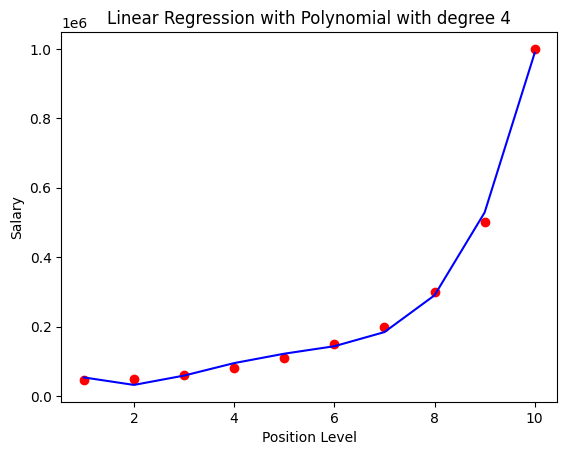

In [44]:
viz_polynomial()

In [18]:
lin_reg.predict([[5.5]]) # predik salary berdasarkan garis lurus/linear

array([249500.])

In [19]:
pol_reg.predict(poly_reg.fit_transform([[5.5]])) # prediks salary berdasarkan polynomial

array([132148.43750002])